In [39]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt


DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

# playlists = ["1A", "1B", "1E", "1M", "1P", "1D", "1L", "1G", "1O", "1C", "1F", "1A", "1N"]

# Eval playlists; for now only 1A
playlists = ["1A"] 

training_names = {
  "LogMSE": {
    "Transformer": "E_avail_LogMSE_20260224_062703",
    #"OmniLearned_Small": "E_avail_LogMSE_resume1_1A_20260224_191846",
    #"OmniLearned_Small_Pretrained": "E_avail_LogMSE_PT_resume1_1A_20260224_191600"
  },
  "HuberW": {
    "Transformer": "E_avail_HuberEWeighted_20260224_131609",
    "OmniLearned_Small": "E_avail_HuberWeighted_NoLog_Cont1_1A_20260224_235204",
    "OmniLearned_Small_Pretrained": "E_avail_HuberWeighted_PT_NoLog_Cont1_1A_20260224_235125"
  }
}


In [40]:
def eval_commands(trainings):
    for loss in trainings.keys():
        for model in trainings[loss].keys():
            if "omnilearned" in model.lower():
                print(f"omnilearned evaluate -i {CKPT_DIR}/{trainings[loss][model]} --num-workers 2 --batch 100")
            else:
                print(f"python -m src.scripts.eval --checkpoint {CKPT_DIR}/{trainings[loss][model]} --batch_size 1024 --dataset_name minerva_1A --no_amp")
print("")
eval_commands(training_names)




python -m src.scripts.eval --checkpoint /global/cfs/cdirs/m3246/gregork/checkpoints/E_avail_LogMSE_20260224_062703 --batch_size 1024 --dataset_name minerva_1A --no_amp
python -m src.scripts.eval --checkpoint /global/cfs/cdirs/m3246/gregork/checkpoints/E_avail_HuberEWeighted_20260224_131609 --batch_size 1024 --dataset_name minerva_1A --no_amp
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/E_avail_HuberWeighted_NoLog_Cont1_1A_20260224_235204 --num-workers 2 --batch 100
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/E_avail_HuberWeighted_PT_NoLog_Cont1_1A_20260224_235125 --num-workers 2 --batch 100


In [41]:
results = {}
configs = {}

for loss in training_names.keys():
    results[loss] = {}
    configs[loss] = {}
    for model in training_names[loss].keys():
        results[loss][model] = {}
        configs[loss][model] = {}
        # File looks like this: CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
        results[loss][model] = {}
        configs[loss][model] = {}
        for playlist in playlists:
            path1 = CKPT_DIR / training_names[loss][model] / "test_results" / f"outputs_{training_names[loss][model]}_minerva_{playlist}_0.npz"
            path2 = CKPT_DIR / training_names[loss][model] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
            if path1.exists():
                results[loss][model][playlist] = dict(np.load(path1))
            elif path2.exists():
                results[loss][model][playlist] = dict(np.load(path2))
            else:
                raise ValueError(f"No results found for {training_names[loss][model]} on playlist {playlist} - {path1} and {path2} do not exist")
            results[loss][model][playlist]["prediction"][results[loss][model][playlist]["prediction"] < 0] = 0
            settings_path = CKPT_DIR / training_names[loss][model] / "settings.json"
            if settings_path.exists():
                configs[loss][model][playlist] = json.load(open(settings_path, "rb"))
            else:
                print(f"No settings found for {training_names[loss][model]} on playlist {playlist}")
                configs[loss][model][playlist] = {}


No settings found for E_avail_LogMSE_20260224_062703 on playlist 1A
No settings found for E_avail_HuberEWeighted_20260224_131609 on playlist 1A


In [42]:
data_paths = {}
for loss in training_names.keys():
    data_paths[loss] = {}
    for model in training_names[loss]:
        data_paths[loss][model] = {}
        for playlist in playlists:
            data_paths[loss][model][playlist] = {}
            model_path = CKPT_DIR / training_names[loss][model] / "best_model.pt"
            if os.path.exists(model_path):
                data_paths[loss][model][playlist] = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))["args"]["data_path"]
            else:
                print(f"No best model found for {training_names[loss][model]} on playlist {playlist}")
                del data_paths[loss][model][playlist]

No best model found for E_avail_HuberWeighted_NoLog_Cont1_1A_20260224_235204 on playlist 1A
No best model found for E_avail_HuberWeighted_PT_NoLog_Cont1_1A_20260224_235125 on playlist 1A


In [43]:
truth_labels = {}
for loss in data_paths.keys():
    truth_labels[loss] = {}
    for model in data_paths[loss].keys():
        truth_labels[loss][model] = {}
        for playlist in data_paths[loss][model].keys():
            truth_labels[loss][model][playlist] = torch.load(open(Path(data_paths[loss][model][playlist]) /  playlist / "test" / "0.pb", "rb"), weights_only=False, map_location=torch.device("cpu"))["truth_labels"]

In [44]:
E_true_dict, E_pred_dict = {}, {}  # eval dataset -> loss -> model -> E_true or E_pred in GeV
E_pred_over_true_dict = {}
for dataset in playlists:
    E_true_dict[dataset] = {}
    E_pred_dict[dataset] = {}
    E_pred_over_true_dict[dataset] = {}
    for loss in data_paths.keys():
        E_true_dict[dataset][loss] = {}
        E_pred_dict[dataset][loss] = {}
        E_pred_over_true_dict[dataset][loss] = {}
        for model in data_paths[loss].keys():
            E_true_dict[dataset][loss][model] = results[loss][model][dataset]["pid"].flatten()
            E_pred_dict[dataset][loss][model] = results[loss][model][dataset]["prediction"].flatten()
            E_pred_over_true = E_pred_dict[dataset][loss][model] / E_true_dict[dataset][loss][model]
            E_pred_over_true_dict[dataset][loss][model] = E_pred_over_true


/tmp/ipykernel_610027/2819346453.py:14: RuntimeWarning: divide by zero encountered in divide
  E_pred_over_true = E_pred_dict[dataset][loss][model] / E_true_dict[dataset][loss][model]
/tmp/ipykernel_610027/2819346453.py:14: RuntimeWarning: invalid value encountered in divide
  E_pred_over_true = E_pred_dict[dataset][loss][model] / E_true_dict[dataset][loss][model]


In [45]:
Enu_baselines = {}
Enu_filters = {}
mc_E = {}

loss = "LogMSE"
model = "Transformer"

for eval_dataset in configs[loss][model]:
    mc_E[eval_dataset] = E_true_dict[eval_dataset][loss][model]
    if eval_dataset not in Enu_baselines:
        Enu_baselines[eval_dataset] = {}
        Enu_filters[eval_dataset] = {}
    settings = configs[loss][model][eval_dataset]
    if "path" not in settings:
        settings["path"] = data_paths[loss][model][eval_dataset]
    split_idx = os.path.join(settings["path"], "result.pkl")
    split_idx = pickle.load(open(split_idx, "rb"))
    current_baselines = os.path.join(settings["path"], "baselines", f"{eval_dataset}_enu_baselines.npz")
    current_baselines = np.load(current_baselines, mmap_mode="r")
    for key in current_baselines.keys():
        if key in ["muon_filter_CC_paper", "q0", "q3"]:
            Enu_filters[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]]
            if key in ["q0", "q3"]:
                # Divide by 1000
                Enu_filters[eval_dataset][key] = Enu_filters[eval_dataset][key] / 1000
        elif key in ["E_recoil_CCinc_only"]:
            idx_mask = split_idx[eval_dataset]["test_idx"]
            Enu_baselines[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]] / 1000
            # Now set the 0s to -1
            Enu_baselines[eval_dataset][key][Enu_baselines[eval_dataset][key] == 0] = -1


In [47]:
#y_true = results["LogMSE"]["OmniLearned_Small_Pretrained"]["1A"]["pid"]
#y_pred = results["LogMSE"]["OmniLearned_Small_Pretrained"]["1A"]["prediction"].flatten()


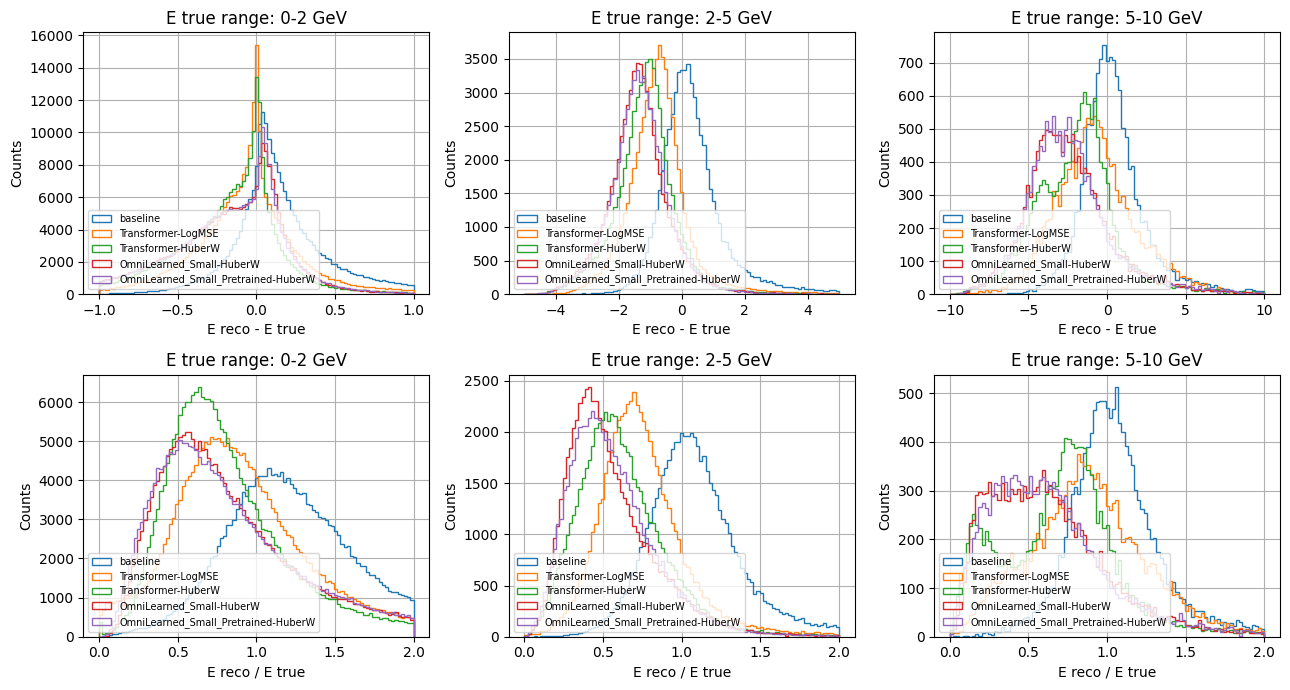

In [60]:
dataset_to_plot = "1A"

fig, ax = plt.subplots(2, 3, figsize=(13, 7))

residual_bins = [np.linspace(-1, 1, 100), np.linspace(-5, 5, 100), np.linspace(-10, 10, 100)]
ratio_bins = [np.linspace(0, 2, 100), np.linspace(0, 2, 100), np.linspace(0, 2, 100)]

# Event selection criteria
mask_filter_event = Enu_filters[dataset_to_plot]["muon_filter_CC_paper"]
mask_is_reco_baseline = Enu_baselines[dataset_to_plot]["E_recoil_CCinc_only"] >= 0
mask_event_selection_criteria = mask_filter_event & mask_is_reco_baseline

energy_bins = [0, 2, 5, 10, 100]

for i in range(3):
    mask_current_plot = (mc_E[dataset_to_plot] > energy_bins[i]) & (mc_E[dataset_to_plot] < (energy_bins)[i+1])
    mask = mask_current_plot & mask_event_selection_criteria
    baseline = Enu_baselines[dataset_to_plot]["E_recoil_CCinc_only"][mask]
    true = mc_E[dataset_to_plot][mask]
    valid_ratio = true > 0
    baseline_over_true = baseline[valid_ratio] / true[valid_ratio]
    ax[0, i].hist(baseline-true, bins=residual_bins[i], histtype="step", label="baseline")
    ax[1, i].hist(baseline_over_true, bins=ratio_bins[i], histtype="step", label="baseline")
    for loss in results:
        for model in results[loss]:
            reco = E_pred_dict[dataset_to_plot][loss][model][mask]
            
            reco_minus_true = reco - true
            ax[0, i].hist(reco_minus_true, bins=residual_bins[i], histtype="step", label=model + "-"+loss)
            
            reco_over_true = reco[valid_ratio] / true[valid_ratio]
            ax[1, i].hist(reco_over_true, bins=ratio_bins[i], histtype="step", label=model + "-"+loss)

    ax[0, i].legend(loc="lower left", fontsize=7)
    ax[0, i].grid()
    ax[0, i].set_xlabel("E reco - E true")
    ax[0, i].set_ylabel("Counts")
    ax[0, i].set_title(f"E true range: {['0-2', '2-5', '5-10', '10+'][i]} GeV")

    ax[1, i].legend(loc="lower left", fontsize=7)
    ax[1, i].grid()
    ax[1, i].set_xlabel("E reco / E true")
    ax[1, i].set_ylabel("Counts")
    ax[1, i].set_title(f"E true range: {['0-2', '2-5', '5-10', '10+'][i]} GeV")

fig.tight_layout()
fig.show()

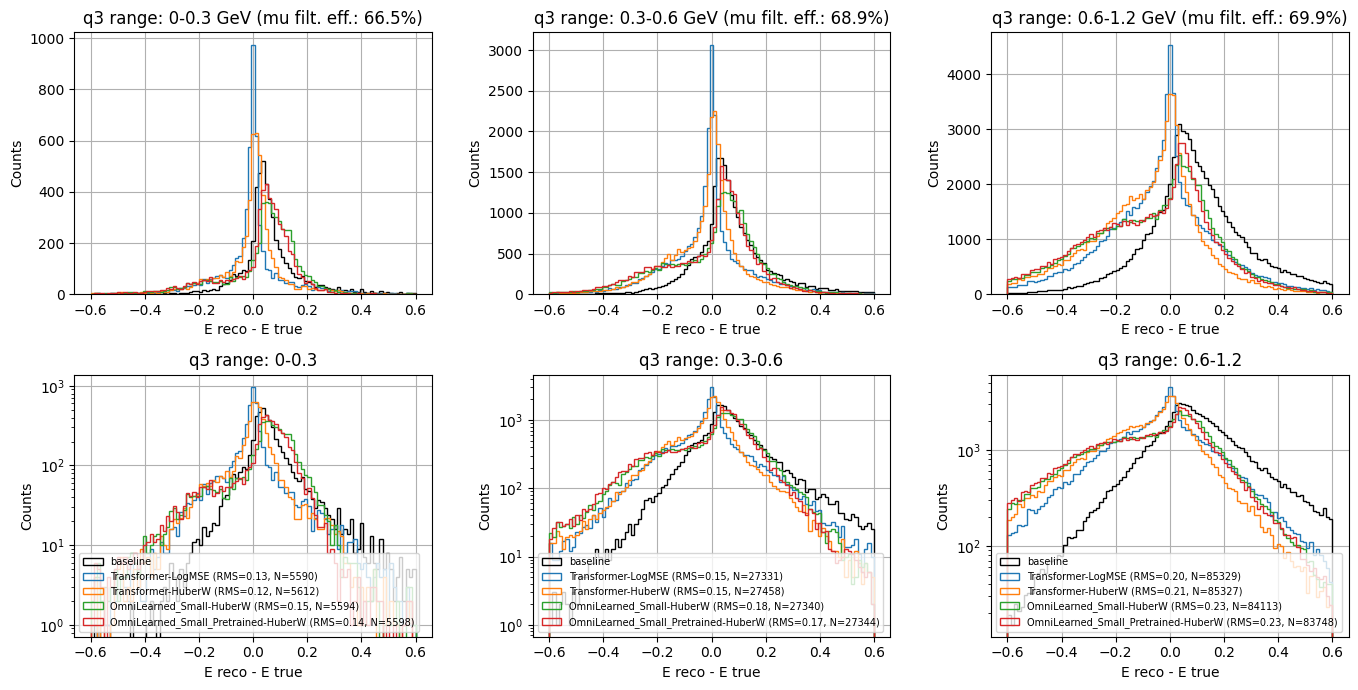

In [99]:
# For the same experiments, plot E reco - E true on three plots, for e true ranges [0, 2], [2, 5], [5, 10], [10+]

fig, ax = plt.subplots(2, 3, figsize=(14, 7))
# Do a MC q3 filter. 0 to 0.3, 0.3 to 0.6, 0.6 to 1.2

mask_filter_event = Enu_filters[dataset_to_plot]["muon_filter_CC_paper"]
mask_is_reco_baseline = Enu_baselines[dataset_to_plot]["E_recoil_CCinc_only"] >= 0
mask_event_selection_criteria = mask_filter_event & mask_is_reco_baseline


q3 = Enu_filters[dataset_to_plot]["q3"]
q3_bins = [0, 0.3, 0.6, 1.2, 100]
IQR_reco_minus_true = {} # loss -> model -> IQR array
RMS_reco_minus_true = {} # loss -> model -> RMS array
IQR_baseline, RMS_baseline = [], []

for i in range(3):
    mask_original = (q3 > q3_bins[i]) & (q3 <= q3_bins[i+1])
    mask = mask_original & mask_event_selection_criteria
    bins = [np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100)]
    efficiency = mask.sum() / mask_original.sum() * 100
    true = mc_E[dataset_to_plot][mask]
    baseline = Enu_baselines[dataset_to_plot]["E_recoil_CCinc_only"][mask]
    ax[0, i].hist(baseline-true, bins=bins[i], histtype="step", label="baseline", color="black")
    ax[1, i].hist(baseline-true, bins=bins[i], histtype="step", label="baseline", color="black")
    iqr = np.percentile(baseline-true, 75) - np.percentile(baseline-true, 25)
    rms = np.sqrt(np.mean(((baseline-true)[np.abs(baseline-true) < 0.6])**2))
    IQR_baseline.append(iqr)
    RMS_baseline.append(rms)
    
    for loss in results:
        if loss not in IQR_reco_minus_true:
            IQR_reco_minus_true[loss] = {}
            RMS_reco_minus_true[loss] = {}
        for model in results[loss]:
            if model not in IQR_reco_minus_true[loss]:
                IQR_reco_minus_true[loss][model] = []
                RMS_reco_minus_true[loss][model] = []
            reco = E_pred_dict[dataset_to_plot][loss][model][mask]
            reco_minus_true = reco - true
            #rms = np.sqrt(np.mean((reco_minus_true[np.abs(reco_minus_true) < 0.6])**2))
            IQR = np.percentile(reco_minus_true, 75) - np.percentile(reco_minus_true, 25)
            IQR_reco_minus_true[loss][model].append(IQR)
            RMS = np.sqrt(np.mean((reco_minus_true[np.abs(reco_minus_true) < 0.6])**2))
            RMS_reco_minus_true[loss][model].append(RMS)
            N_events_in_histogram = np.sum(np.abs(reco_minus_true) < 0.6)
            ax[0, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=f"{model}-{loss} (RMS={RMS:.2f}, N={N_events_in_histogram})")
            ax[1, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=f"{model}-{loss} (RMS={RMS:.2f}, N={N_events_in_histogram})")
    ax[0, i].grid()
    ax[0, i].set_xlabel("E reco - E true")
    ax[0, i].set_ylabel("Counts")
    ax[0, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]} GeV (mu filt. eff.: {efficiency:.1f}%)")
    ax[1, i].legend(loc="lower left", fontsize=7)
    ax[1, i].grid()
    ax[1, i].set_xlabel("E reco - E true")
    ax[1, i].set_ylabel("Counts")
    ax[1, i].set_yscale("log")
    ax[1, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]}")

fig.tight_layout()
fig.show()

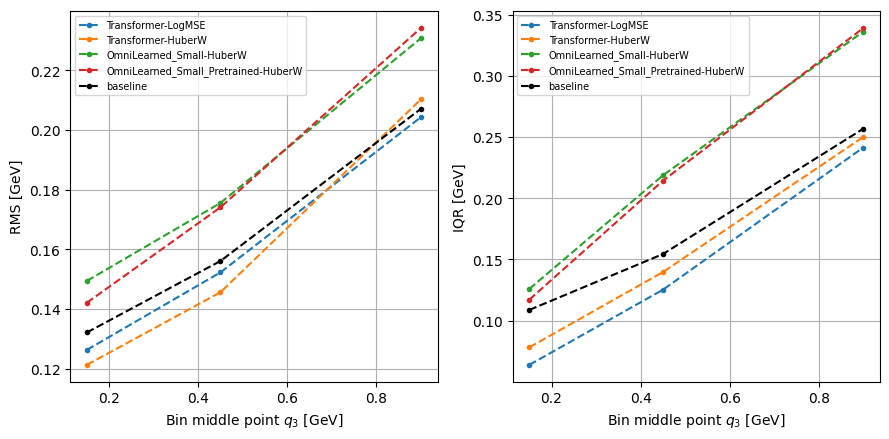

In [ ]:
# Make a q3 bin middle vs RMS_reco_minus_true plot as well as IQR_reco_minus_true. Make the IQR and RMS axes different (left IQR, right RMS)
N_bins = len(q3_bins) - 1
q3_bins = np.array(q3_bins)
q3_bin_mids = (q3_bins[:-1] + q3_bins[1:]) / 2
q3_bin_mids = q3_bin_mids[:-1]

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
for loss in results.keys():
    for model in results[loss].keys():
        ax[0].plot(q3_bin_mids, np.array(RMS_reco_minus_true[loss][model]), ".--", label=f"{model}-{loss}")
        ax[1].plot(q3_bin_mids, np.array(IQR_reco_minus_true[loss][model]), ".--", label=f"{model}-{loss}")

ax[0].plot(q3_bin_mids, np.array(RMS_baseline), ".--", label="baseline", color="black")
ax[1].plot(q3_bin_mids, np.array(IQR_baseline), ".--", label="baseline", color="black")
ax[0].legend(fontsize=7)
ax[1].legend(fontsize=7)
ax[0].set_xlabel("Bin middle point $q_3$ [GeV]")
ax[1].set_xlabel("Bin middle point $q_3$ [GeV]")
ax[0].set_ylabel("RMS [GeV]")
ax[1].set_ylabel("IQR [GeV]")
ax[0].grid()
ax[1].grid()


fig.tight_layout()
fig.show()
